# Time Series Forecasting

#### Imports

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import datetime
import datetime
import math
import pickle

global Matplotlib standard figuresize

In [3]:
plt.rcParams['figure.figsize'] = [12, 8]

set max columns

In [4]:
pd.set_option('display.max_columns', 50)

set print options

In [5]:
np.set_printoptions(threshold=10)#np.inf

set column width

In [6]:
pd.set_option('display.max_colwidth', 50)

Get Datasets from Preprocessing

In [3]:
X = pickle.load(open("X_ds_8h.p","rb"))

In [4]:
y = pickle.load(open("y_ds_8h.p","rb"))

In [5]:
X[0]

,n_steps_in_Q,Q_size,n_added,n_removed
0,1,2361,0,0
1,2,2358,0,3
2,3,2355,0,3
3,4,2351,0,4
4,5,2348,0,3
5,6,2343,0,5
6,7,2339,0,4
7,8,2335,0,4
8,9,2333,0,2
9,10,2330,0,3


In [6]:
y[0]

0     11
1     10
2      9
3      8
4      7
5      6
6      5
7      4
8      3
9      2
10     1
Name: 1001383363, dtype: int64

## Train Test Split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
def split_train_test(X, y, **kwargs):
    X_train, X_test, y_train, y_test = train_test_split(X, y, **kwargs)
    X_train = np.vstack([x.values for x in X_train])
    X_test = np.vstack([x.values for x in X_test])
    y_train = np.concatenate([y.values for y in y_train])
    y_test = np.concatenate([y.values for y in y_test])
    return X_train, X_test, y_train, y_test

In [9]:
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.1, shuffle=False)

In [10]:
X_train.shape

(870069, 4)

In [11]:
X_train[0]

array([   1, 2361,    0,    0])

In [12]:
y_train[0]

11

## Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Scoring

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, r2_score
from sklearn import metrics

In [17]:
def mape(y_pred, y_true):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [18]:
def get_score(y_test, pred_test, output=True):

    mse = mean_squared_error(y_test, pred_test)
    rmse = math.sqrt(mean_squared_error(y_test, pred_test))
    mae = mean_absolute_error(y_test, pred_test)
    mape_score = mape(y_test, pred_test)
    r2 = r2_score(y_test, pred_test)

    if output == True:
        print('MSE : {0}'.format(mse))
        print('RMSE: {0}'.format(rmse))
        print('MAE : {0}'.format(mae))
        print('MAPE: {0}'.format(mape_score))
        print('R2  : {0}'.format(r2))
    else:
        return [mse, rmse, mae, mape_score, r2]

## Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
model_lr = LinearRegression(fit_intercept=True)

In [21]:
model_lr.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [22]:
pred = model_lr.predict(X_test)

In [23]:
get_score(y_test, pred)

MSE : 28801.920563509437
RMSE: 169.7112859049434
MAE : 139.11667948136477
MAPE: 51.23670148495779
R2  : 0.23186750178170767


In [24]:
pred[0]

404.71883247865156

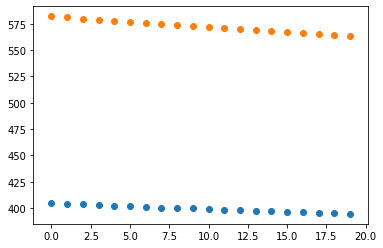

In [25]:
plt.scatter(range(20), pred[:20])
plt.scatter(range(20), y_test[:20])

## Decision Trees

In [26]:
from sklearn.tree import DecisionTreeRegressor

In [27]:
model_dt = DecisionTreeRegressor(random_state=0)

In [28]:
model_dt.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=0, splitter='best')

In [29]:
pred = model_dt.predict(X_test)

In [30]:
get_score(y_test, pred)

MSE : 27981.634900333876
RMSE: 167.27712007424648
MAE : 134.39620077814675
MAPE: 49.44751095848547
R2  : 0.25374410109800394


In [31]:
pred[0]

400.9342414279004

In [32]:
y_test[0]

582

In [33]:
X_test[0]

array([-1.40273165,  1.43003551, -0.16853837, -2.93241494])

In [34]:
pred

array([400.93424143, 400.4985889 , 400.06311823, ..., 157.95189873,
       157.75063613, 157.35121328])

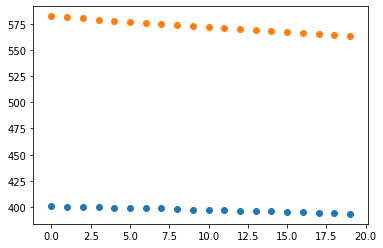

In [35]:
plt.scatter(range(20), pred[:20])
plt.scatter(range(20), y_test[:20])

## Gaussian Naive Bayes

In [36]:
from sklearn.naive_bayes import GaussianNB

In [37]:
model_gnb = GaussianNB()

In [38]:
model_gnb.fit(X_train, y_train)

GaussianNB(priors=None, var_smoothing=1e-09)

In [39]:
pred = model_gnb.predict(X_test)

In [40]:
get_score(y_test, pred)

MSE : 78038.50690875176
RMSE: 279.35373079440296
MAE : 211.2170655799195
MAPE: 236.49071529787795
R2  : -1.0812470868692983


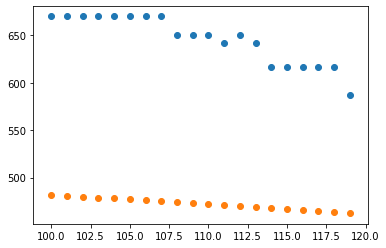

In [41]:
plt.scatter(range(100,120), pred[100:120])
plt.scatter(range(100,120), y_test[100:120])